In [24]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns; sns.set()

# Working with Perfectly Linear Dataset

In [25]:
from sklearn.datasets import make_blobs

In [26]:
X,y=make_blobs(n_samples=50,centers=2,random_state=0,cluster_std=0.60)

In [27]:
X

array([[ 1.41281595,  1.5303347 ],
       [ 1.81336135,  1.6311307 ],
       [ 1.43289271,  4.37679234],
       [ 1.87271752,  4.18069237],
       [ 2.09517785,  1.0791468 ],
       [ 2.73890793,  0.15676817],
       [ 3.18515794,  0.08900822],
       [ 2.06156753,  1.96918596],
       [ 2.03835818,  1.15466278],
       [-0.04749204,  5.47425256],
       [ 1.71444449,  5.02521524],
       [ 0.22459286,  4.77028154],
       [ 1.06923853,  4.53068484],
       [ 1.53278923,  0.55035386],
       [ 1.4949318 ,  3.85848832],
       [ 1.1641107 ,  3.79132988],
       [ 0.74387399,  4.12240568],
       [ 2.29667251,  0.48677761],
       [ 0.44359863,  3.11530945],
       [ 0.91433877,  4.55014643],
       [ 1.67467427,  0.68001896],
       [ 2.26908736,  1.32160756],
       [ 1.5108885 ,  0.9288309 ],
       [ 1.65179125,  0.68193176],
       [ 2.49272186,  0.97505341],
       [ 2.33812285,  3.43116792],
       [ 0.67047877,  4.04094275],
       [-0.55552381,  4.69595848],
       [ 2.16172321,

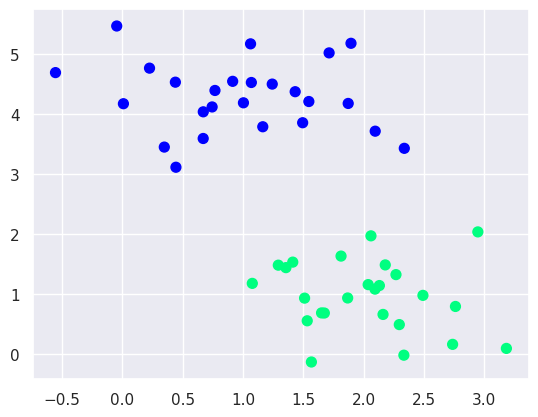

In [28]:
plt.scatter(X[:, 0],X[:, 1],c=y,s=50,cmap='winter')

In [29]:
from sklearn.svm import SVC
m=SVC(kernel='linear',C=1)

In [30]:
m.fit(X,y)

SVC(C=1, kernel='linear')

In [31]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """
    Plot the decision function for a 2D SVM.
    """

    if ax is None:
        ax = plt.gca()

    # Get current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)

    # Evaluate decision function
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = m.decision_function(xy).reshape(X.shape)

    # Plot decision boundary and margins
    ax.contour(
        X, Y, P,
        colors='k',
        levels=[-1, 0, 1],
        alpha=0.5,
        linestyles=['--', '-', '--']
    )

    # Plot support vectors
    if plot_support:
        ax.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=300,
            linewidth=1,
            facecolors='none',
            edgecolors='k'
        )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

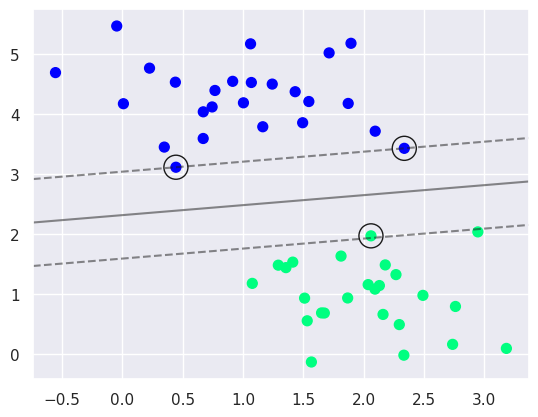

In [32]:
plt.scatter(X[:, 0],X[:, 1],c=y,s=50,cmap='winter')
plot_svc_decision_function(m)

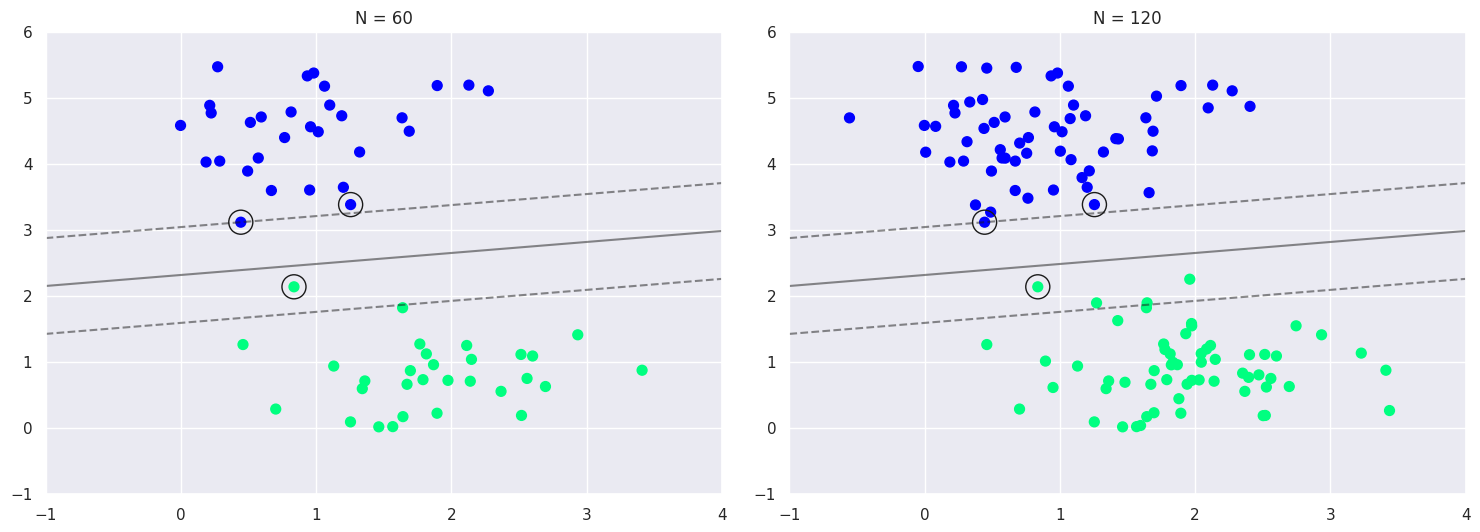

In [33]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(
        n_samples=200,
        centers=2,
        random_state=0,
        cluster_std=0.60
    )

    X = X[:N]
    y = y[:N]

    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()

    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')

    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)

    plot_svc_decision_function(model, ax)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

fig.subplots_adjust(
    left=0.0625,
    right=0.95,
    wspace=0.1
)

for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

plt.show()

In [34]:
X,y=make_blobs(n_samples=100,centers=2,random_state=0,cluster_std=1.2)

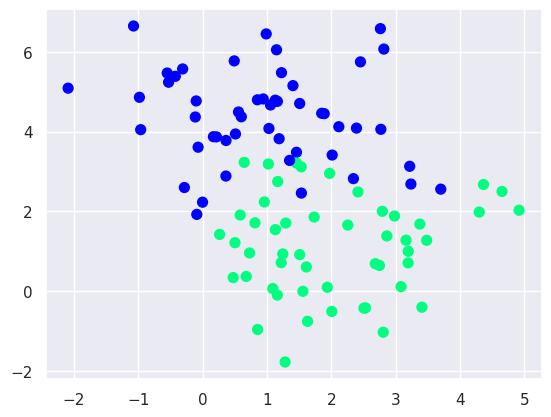

In [35]:
plt.scatter(X[:, 0],X[:, 1],c=y,s=50,cmap='winter')

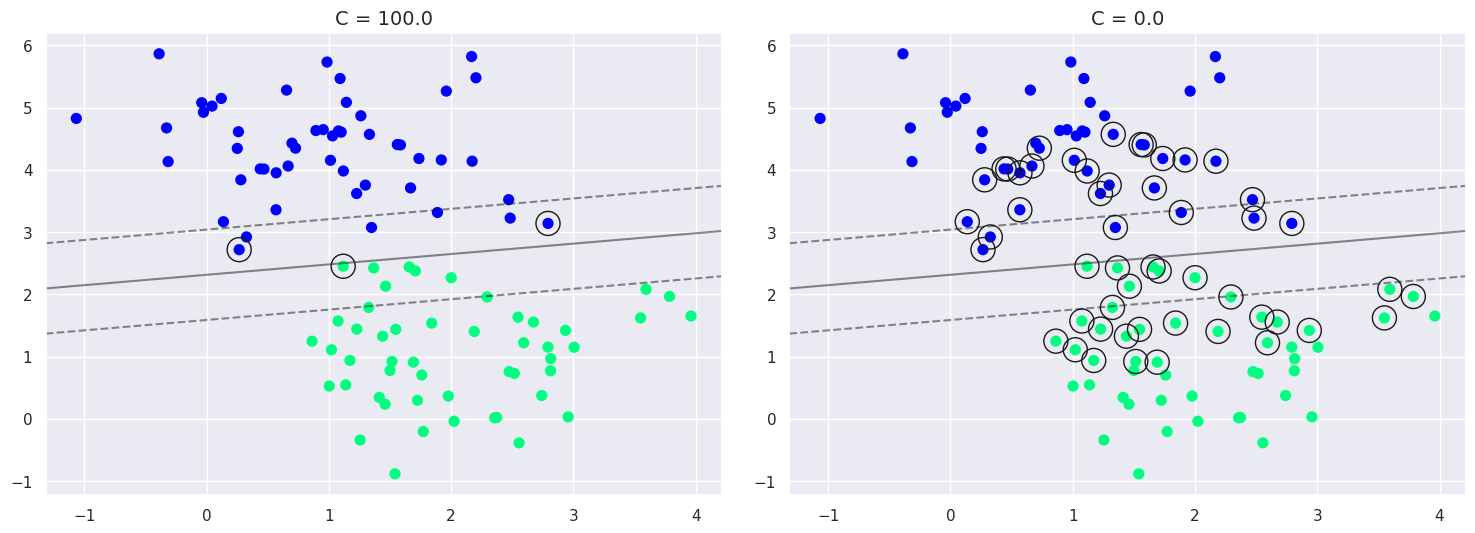

In [39]:
X, y = make_blobs(
    n_samples=100,
    centers=2,
    random_state=0,
    cluster_std=0.8
)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(
    left=0.0625,
    right=0.95,
    wspace=0.1
)

for axi, C in zip(ax, [100.0, 0.01]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=300,
        lw=1,
        facecolors='none'
    )
    axi.set_title('C = {0:.1f}'.format(C), size=14)

plt.show()